El Harraj Imane

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv("../data/CO2_emission.csv")
df.head()

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105


In [ ]:
X_train = df[['Weight', 'Volume']].values
y = df["CO2"].values

In [ ]:
X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)

In [ ]:
def cost_function(X, y, w, b):
    m = X.shape[0]
    f_wb = np.dot(X, w) + b
    cost = np.sum((f_wb - y)**2)
    return (1 / (2 * m)) * cost

In [ ]:
def gradient_function(X, y, w, b):
    m, n = X.shape
    f_wb = np.dot(X, w) + b
    err = f_wb - y
    
    dj_dw = (1/m) * np.dot(X.T, err)
    dj_db = (1/m) * np.sum(err)
    
    return dj_dw, dj_db

In [ ]:
def gradient_descent(X, y, alpha, iterations):
    m, n = X.shape
    w = np.zeros(n) 
    b = 0.0

    costs = []
    
    for i in range(iterations):
        dj_dw, dj_db = gradient_function(X, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = cost_function(X, y, w, b)
        costs.append(cost)
      
        if i % 100 == 0 :
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b):.2f}")
            
    return w, b, costs

In [ ]:
learning_rate = 0.01
iterations = 1000

final_w, final_b, costs = gradient_descent(X_train, y, learning_rate, iterations)

print(f"w: {final_w}")
print(f"b: {final_b:.4f}")

Iteration 0: Cost 5127.92
Iteration 100: Cost 700.64
Iteration 200: Cost 108.45
Iteration 300: Cost 29.13
Iteration 400: Cost 18.50
Iteration 500: Cost 17.07
Iteration 600: Cost 16.88
Iteration 700: Cost 16.85
Iteration 800: Cost 16.84
Iteration 900: Cost 16.84
w: [1.85317654 2.94310277]
b: 102.0234


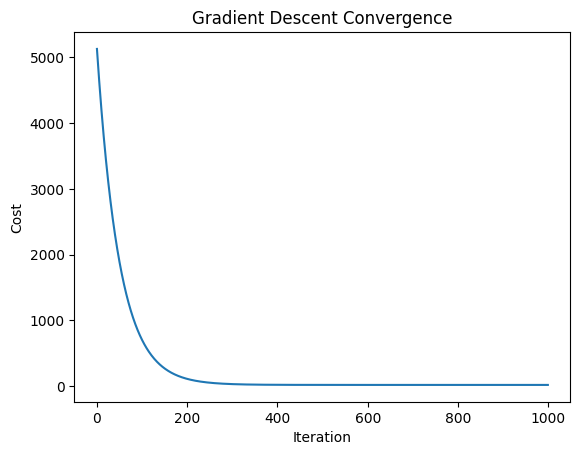

In [ ]:
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()

In [ ]:
X_new = np.array([2300, 1300])

X_new_scaled = (X_new - np.mean(df[['Weight', 'Volume']].values, axis=0)) / np.std(df[['Weight', 'Volume']].values, axis=0)

prediction = np.dot(X_new_scaled, final_w) + final_b
print(f"Predicted CO2: {prediction}")

Predicted CO2: 107.45837072430447
